# Chuẩn bị và kiểm tra dữ liệu

Chạy từ trên xuống một lần trước các notebook mô hình. Toàn bộ code ở ngay trong
notebook; không cần `config.py` hay `src/`. Giữ nguyên split và nhãn gốc.
Ảnh méo sẵn không thể sửa chỉ bằng resize; không đổi nhãn theo dự đoán model.

## 1. Import và đường dẫn

Đổi `DATASET_ROOT` nếu dữ liệu nằm ở nơi khác. Thư mục này phải chứa
`train/`, `val/`, `test/`, mỗi tập có bốn thư mục lớp.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

ROOT = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
DATASET_ROOT = ROOT.parent / 'dataset/Forect Fire/Forest Fire_Dataset'
DATA_DIR = ROOT / 'data'
CLASS_NAMES = ['fire', 'nofire', 'smoke', 'smokefire']
IMAGE_SIZE = (224, 224)
DATA_DIR.mkdir(exist_ok=True)
assert DATASET_ROOT.is_dir(), 'Sửa DATASET_ROOT cho đúng vị trí dữ liệu.'

## 2. Đọc ảnh và tạo manifest

Ảnh → RGB → resize 224×224 → JPEG. Mapping cố định: fire=0, nofire=1,
smoke=2, smokefire=3. Direct resize tránh viền padding tương quan với lớp,
nhưng làm biến dạng ảnh không vuông. Ghi SHA256 để kiểm tra trùng chính xác.
File không đọc được hoặc tên không khớp được đánh dấu `review`.

`filepath` được ghi tương đối với `DATASET_ROOT`, cùng quy ước pipeline chung từ main.

In [2]:
rows = []
pattern = re.compile(r'^(fire|nofire|smoke|smokefire)_(train|val|test)_\d+\.jpg$')
for split in ['train', 'val', 'test']:
    for class_index, label in enumerate(CLASS_NAMES):
        folder = DATASET_ROOT / split / label
        assert folder.is_dir(), f'Thiếu thư mục: {folder}'
        paths = sorted(folder.glob('*.jpg'))
        assert paths, f'Thư mục rỗng: {folder}'
        for path in paths:
            destination = DATA_DIR / 'processed' / split / label / path.name
            destination.parent.mkdir(parents=True, exist_ok=True)
            match = pattern.fullmatch(path.name)
            note = '' if match and match.groups() == (label, split) else 'filename_mismatch'
            row = dict(filepath=path.relative_to(DATASET_ROOT).as_posix(),
                       processed_filepath=destination.relative_to(ROOT).as_posix(),
                       split=split, label=label, class_index=class_index,
                       status='ok', note=note)
            try:
                with Image.open(path) as image:
                    row.update(width=image.width, height=image.height, mode=image.mode,
                               image_format=image.format, file_size_bytes=path.stat().st_size,
                               exif_orientation=image.getexif().get(274, 1))
                    image = ImageOps.exif_transpose(image).convert('RGB')
                    image.resize(IMAGE_SIZE, Image.Resampling.LANCZOS).save(
                        destination, quality=95, optimize=True, progressive=True)
                row['raw_sha256'] = hashlib.sha256(path.read_bytes()).hexdigest()
                row['processed_sha256'] = hashlib.sha256(destination.read_bytes()).hexdigest()
            except (OSError, ValueError) as error:
                row['note'] = f'cannot_decode: {error}'
            rows.append(row)
frame = pd.DataFrame(rows)
duplicate = frame['raw_sha256'].duplicated(keep=False) | frame['processed_sha256'].duplicated(keep=False)
frame.loc[duplicate, 'note'] += ';exact_duplicate'
frame.loc[frame['note'] != '', 'status'] = 'review'
frame.loc[frame['note'] == '', 'note'] = 'clean'
frame.to_csv(DATA_DIR / 'split.csv', index=False)
display(pd.crosstab(frame['split'], frame['label'])[CLASS_NAMES])
display(frame['status'].value_counts())
print('Manifest:', DATA_DIR / 'split.csv')
summary = {'dataset_root': Path(os.path.relpath(DATASET_ROOT, ROOT)).as_posix(),
           'processed_data_dir': 'data/processed', 'manifest': 'data/split.csv',
           'resize_policy': 'direct_resize', 'total_images': len(frame), 'image_size': list(IMAGE_SIZE),
           'split_class_counts': pd.crosstab(frame['split'], frame['label'])[CLASS_NAMES].to_dict('index'),
           'status_counts': frame['status'].value_counts().to_dict(),
           'raw_duplicate_files_by_sha256': int(frame['raw_sha256'].duplicated(keep=False).sum()),
           'processed_duplicate_files_by_sha256': int(frame['processed_sha256'].duplicated(keep=False).sum()),
           'raw_exact_target_size_count': int(((frame['width'] == IMAGE_SIZE[0]) & (frame['height'] == IMAGE_SIZE[1])).sum()),
           'top_raw_dimensions': (frame['width'].astype(str) + 'x' + frame['height'].astype(str)).value_counts().to_dict(),
           'notes': frame['note'].value_counts().to_dict()}
(DATA_DIR / 'processed/processing_summary.json').write_text(
    json.dumps(summary, indent=2), encoding='utf-8')
print('EXIF orientation:', frame['exif_orientation'].value_counts().to_dict())

label,fire,nofire,smoke,smokefire
split,,,,
test,200,200,200,200
train,800,800,800,800
val,200,200,200,200


status
ok    4800
Name: count, dtype: int64

Manifest: C:\Users\admin\OneDrive - National Economics University\Documents\TÀI LIỆU\GIÁO TRÌNH HỌC\DEEP NEURAL NETWORK\Fire-and-smoke-detection-using-D-Fire\data\split.csv
EXIF orientation: {1: 4800}


## 3. Xem mẫu và rà nhãn

Xem cả train, validation và test. Tiêu chí: fire = lửa, smoke = khói,
smokefire = cả lửa và khói, nofire = không có cả hai. Ảnh mơ hồ cần đối chiếu
nguồn, không sửa chỉ vì model đoán khác. `status=ok` không chứng minh đúng nhãn.

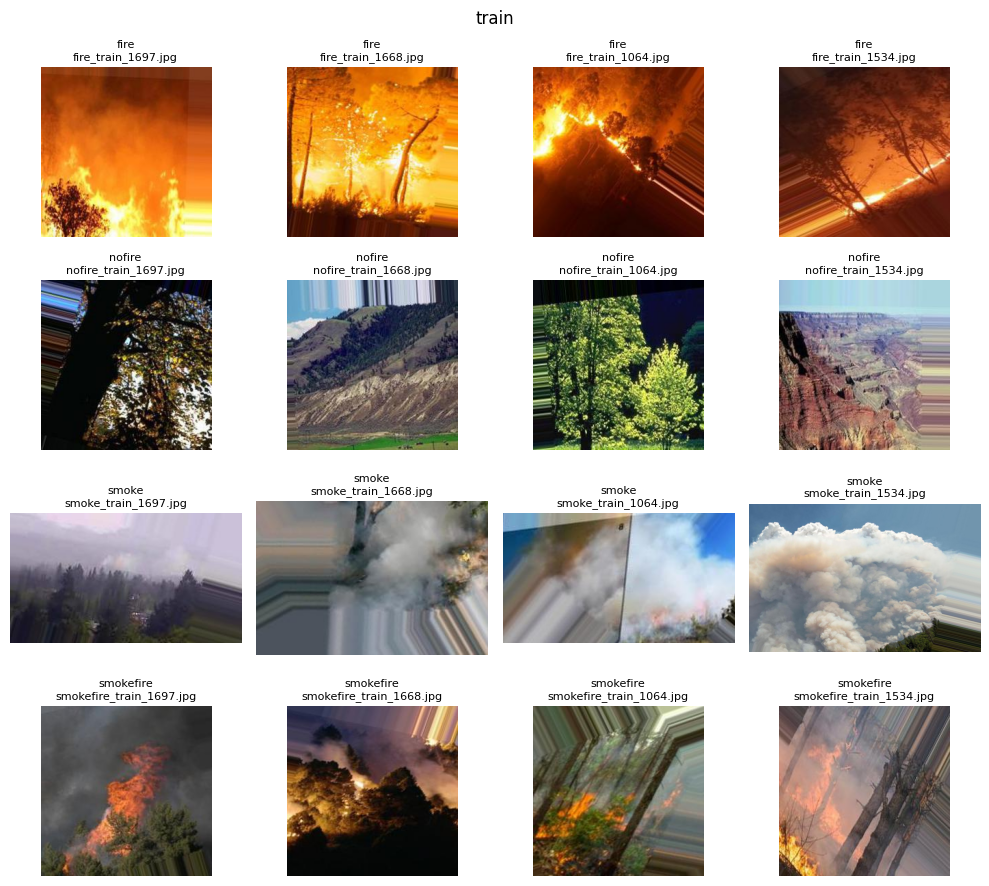

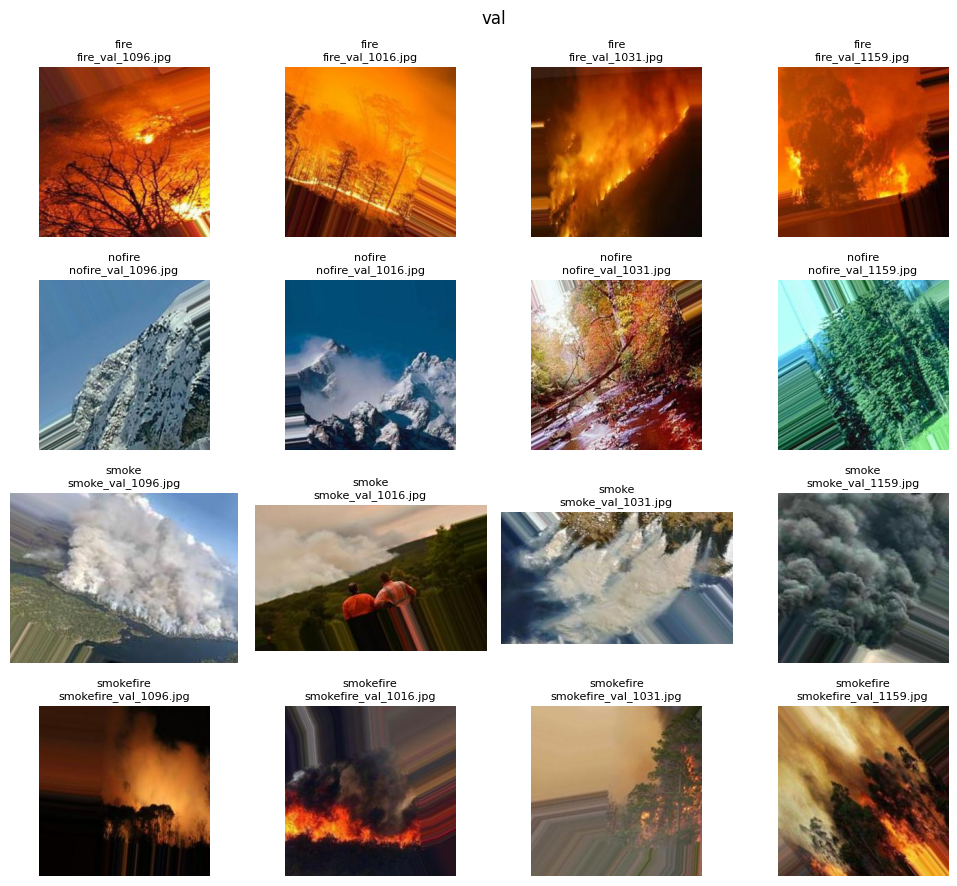

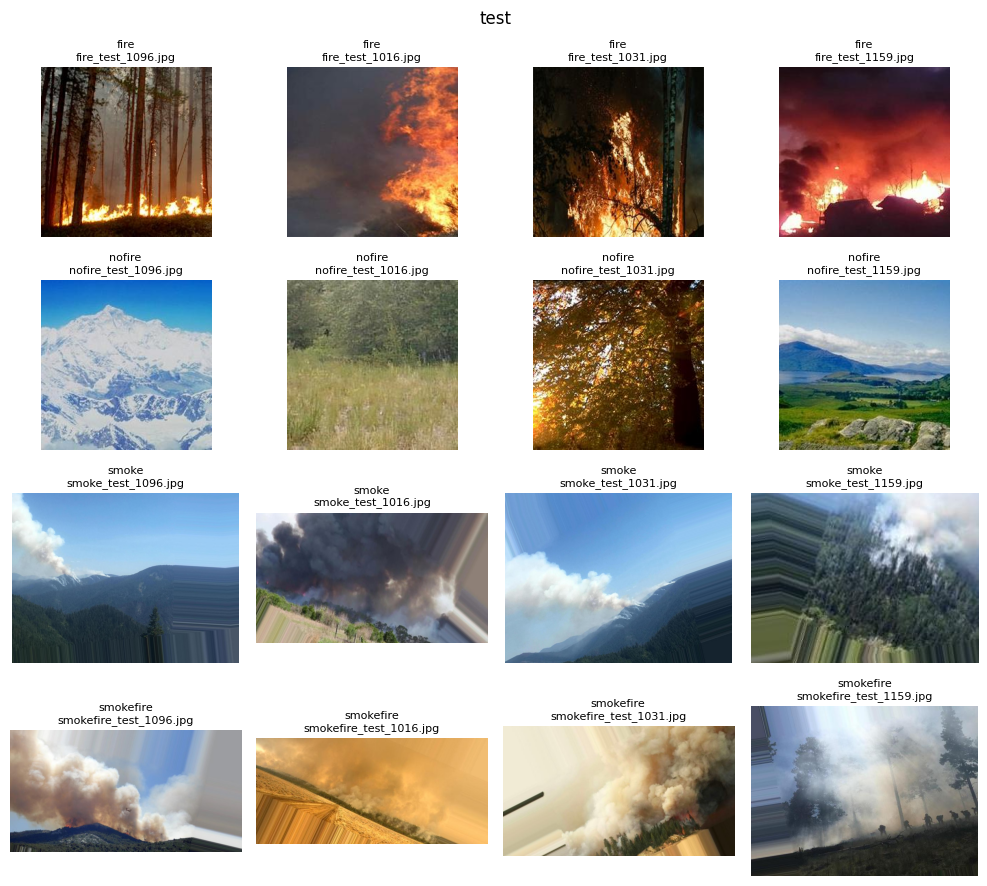

In [3]:
for split in ['train', 'val', 'test']:
    fig, axes = plt.subplots(4, 4, figsize=(10, 9))
    for class_index, label in enumerate(CLASS_NAMES):
        samples = frame[(frame['split'] == split) & (frame['label'] == label)
                        & (frame['status'] == 'ok')].sample(n=4, random_state=42)
        for ax, row in zip(axes[class_index], samples.itertuples()):
            with Image.open(DATASET_ROOT / row.filepath) as image:
                ax.imshow(ImageOps.exif_transpose(image).convert('RGB'))
            ax.set_title(f'{label}\n{Path(row.filepath).name}', fontsize=8)
            ax.axis('off')
    fig.suptitle(split)
    plt.tight_layout()
    plt.show()

## 4. Danh sách cần duyệt

Gộp lỗi dự đoán đã lưu và lỗi đọc file thành danh sách rà soát. File này chỉ là
gợi ý, không tự thay nhãn hoặc loại ảnh khỏi test. Với ảnh kéo sọc, ưu tiên tìm
bản gốc tốt; lưu rõ quyết định trước khi xây lại bộ dữ liệu.

In [ ]:
review = frame[frame['status'] != 'ok'][['filepath', 'split', 'label', 'note']].copy()
for result in (ROOT / 'results').glob('basic_nn*/misclassified.csv'):
    errors = pd.read_csv(result)
    if 'processed_filepath' in errors:
        candidates = frame.merge(errors[['processed_filepath', 'predicted_label']],
                                 on='processed_filepath', how='inner')
        candidates['note'] = 'prediction_disagrees: ' + candidates['predicted_label']
        review = pd.concat([review, candidates[['filepath', 'split', 'label', 'note']]])
review = review.drop_duplicates('filepath').reset_index(drop=True)
review['suggested_label'] = ''
review['decision'] = ''
review_path = DATA_DIR / 'label_review_candidates.csv'
if review_path.exists():
    previous = pd.read_csv(review_path).fillna('')
    review = review.drop(columns=['suggested_label', 'decision']).merge(
        previous[['filepath', 'suggested_label', 'decision']], on='filepath', how='left').fillna('')
review.to_csv(review_path, index=False)
display(review.head(12))
print('Danh sách cần duyệt:', len(review), 'ảnh. Không áp dụng tự động.')